<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Week7_CNNs_RNN_Transformers/Day%202%20%E2%80%94%20Building%20CNNs%20%26%20Transfer%20Learning/Melanoma_Detection_with_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melanoma Detection with CNNs

In this notebook, we build our first real CNN in the training program. Using the **Keras API and TensorFlow**, we will develop and evaluate three distinct Convolutional Neural Network models for image classification, specifically focusing on melanoma detection. We will compare a baseline CNN, a CNN with data augmentation, and a transfer learning approach to determine the most effective strategy.

---

## Step 1: Kaggle Dataset Download and Environment Setup

> Authenticating Google Colab session with Kaggle using an API key (`kaggle.json`), installs the Kaggle command-line tool, downloads the *Melanoma Skin Cancer* dataset, unzips it into a folder named `melanoma_data`, and displays the resulting folder structure.

In [7]:
import os

# Check if the folder exists and count the files
base_path = 'melanoma_data'

if os.path.exists(base_path):
    print("Folder 'melanoma_data' exists!\n")
    for root, dirs, files in os.walk(base_path):
        # Print subdirectories and their image counts
        if len(files) > 0:
            print(f"Path: {root} | Total Files: {len(files)}")
else:
    print("Folder 'melanoma_data' DOES NOT exist yet.")

Folder 'melanoma_data' DOES NOT exist yet.


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import zipfile

zip_path = "/content/drive/MyDrive/Datasets/Skin Cancer Dataset/skin cancer dataset.zip"
extract_path = "/content/melanoma_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import os
print(os.listdir(extract_path))

['train', 'test']


## Step 2: Load the dataset

In [11]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "melanoma_data/train",          # adjust the path
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    seed=42,
    validation_split=0.2,
    subset="training"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "melanoma_data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    seed=42,
    validation_split=0.2,
    subset="validation"
)

class_names = train_ds.class_names
print(class_names)   # should print ['Benign', 'Malignant'] or similar
num_classes = len(class_names)

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
['Benign', 'Malignant']


In [12]:
# Performance: cache + prefetch so the GPU isn't waiting on disk I/O
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
# Normalize pixel values to [0,1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",       # watches validation loss
    patience=3,                # stops if no improvement for 3 epochs in a row
    restore_best_weights=True  # rolls back to the best epoch, not the last one
)

## Step 3  : Baseline CNN (from scratch)

In [35]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Input
import time

model_baseline = Sequential([
    Input(shape=(128, 128, 3)),
    Rescaling(1./255),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

model_baseline.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()
history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)
print(f"Baseline CNN training time: {time.time()-start_time:.1f}s")

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7622 - loss: 0.4898 - val_accuracy: 0.8219 - val_loss: 0.3871
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8235 - loss: 0.3896 - val_accuracy: 0.8379 - val_loss: 0.3650
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8421 - loss: 0.3572 - val_accuracy: 0.8488 - val_loss: 0.3408
Baseline CNN training time: 24.4s


## Step 4 :  Add data augmentation, retrain, compare

In [36]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Input
import time

augment = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

model_aug = Sequential([
    Input(shape=(128, 128, 3)),
    augment,
    Rescaling(1./255),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

model_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()
history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)
print(f"Augmented CNN training time: {time.time()-start_time:.1f}s")

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7463 - loss: 0.5046 - val_accuracy: 0.8215 - val_loss: 0.3724
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8265 - loss: 0.3910 - val_accuracy: 0.8282 - val_loss: 0.3720
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8402 - loss: 0.3684 - val_accuracy: 0.8472 - val_loss: 0.3515
Augmented CNN training time: 19.7s


## Plot both to compare (Matplotlib):

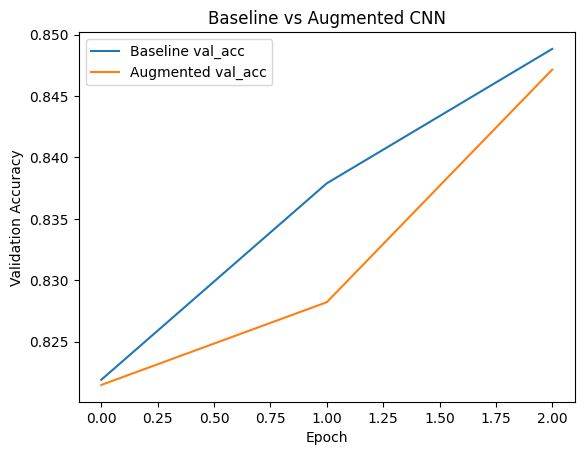

In [38]:
import matplotlib.pyplot as plt

plt.plot(history_baseline.history["val_accuracy"], label="Baseline val_acc")
plt.plot(history_aug.history["val_accuracy"], label="Augmented val_acc")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Baseline vs Augmented CNN")
plt.show()

### Results

*  The  **Baseline model** performed slightly better than the **Augmented model** on the validation set (**87.16%** accuracy vs. **86.32%**).
* **The Reason:**
1. **Too Few Epochs:** Training stopped early. Data augmentation makes learning harder initially, so the augmented model needed more time (epochs) to catch up and show its true potential.
2. **Sub-optimal Settings:** The chosen flips, rotations, or zooms might not have been ideal for skin lesion images.
3. **Regularization Lag:** Augmentation acts like a speed bump to prevent overfitting—it makes the model learn slower, but usually leads to better long-term generalization if given enough training time.


 Even though data augmentation is usually better for real-world performance, it didn't win here because training ended before the augmented model had enough time to peak.

## Step : Transfer learning with MobileNetV2

In [37]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input
import tensorflow as tf

base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(128,128,3))
base.trainable = False  # freeze the pre-trained feature extractor

model_tl = Sequential([
    Input(shape=(128, 128, 3)),
    tf.keras.layers.Lambda(preprocess_input),  # MobileNetV2-specific preprocessing
    base,
    tf.keras.layers.GlobalAveragePooling2D(),   # better than Flatten() for pre-trained backbones
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

model_tl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)
print(f"Transfer learning training time: {time.time()-start_time:.1f}s")

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.8483 - loss: 0.3490 - val_accuracy: 0.8594 - val_loss: 0.3060
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8853 - loss: 0.2702 - val_accuracy: 0.8699 - val_loss: 0.2955
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9009 - loss: 0.2380 - val_accuracy: 0.8712 - val_loss: 0.3101
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9140 - loss: 0.2092 - val_accuracy: 0.8657 - val_loss: 0.3205
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9261 - loss: 0.1842 - val_accuracy: 0.8665 - val_loss: 0.3350
Transfer learning training time: 36.2s


## Some Outputs samples for each model

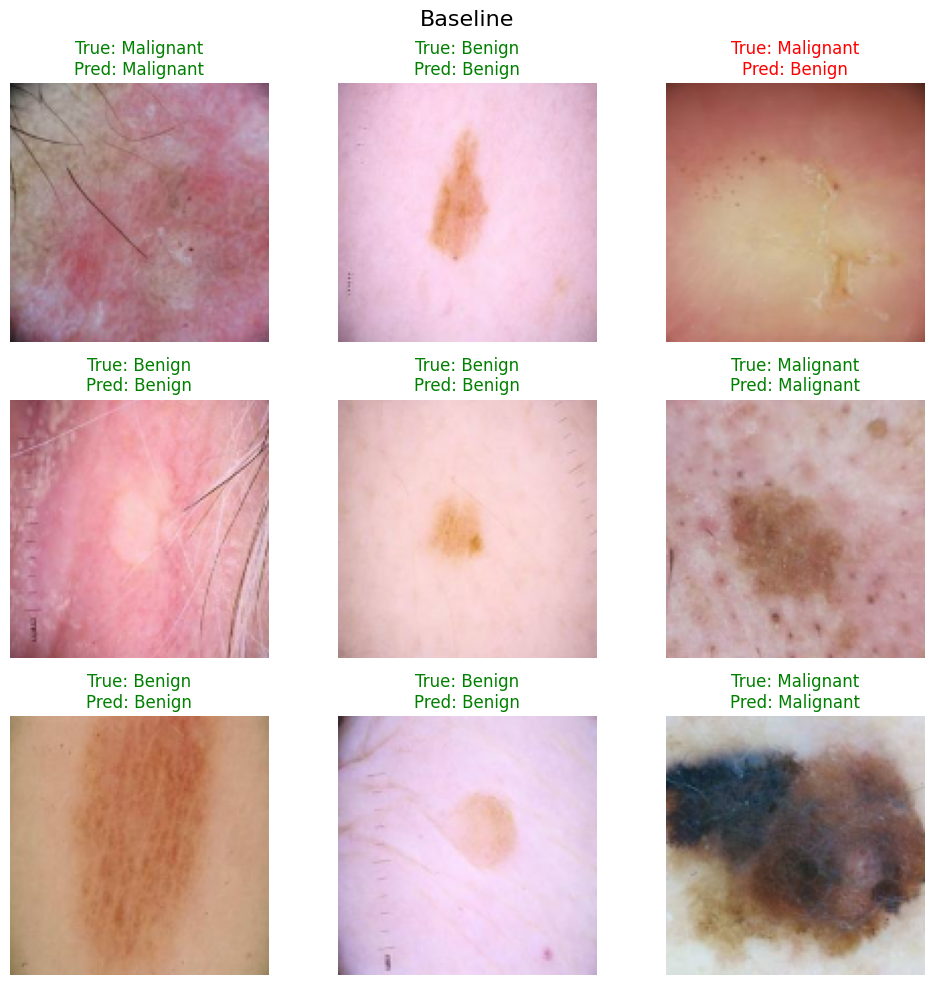

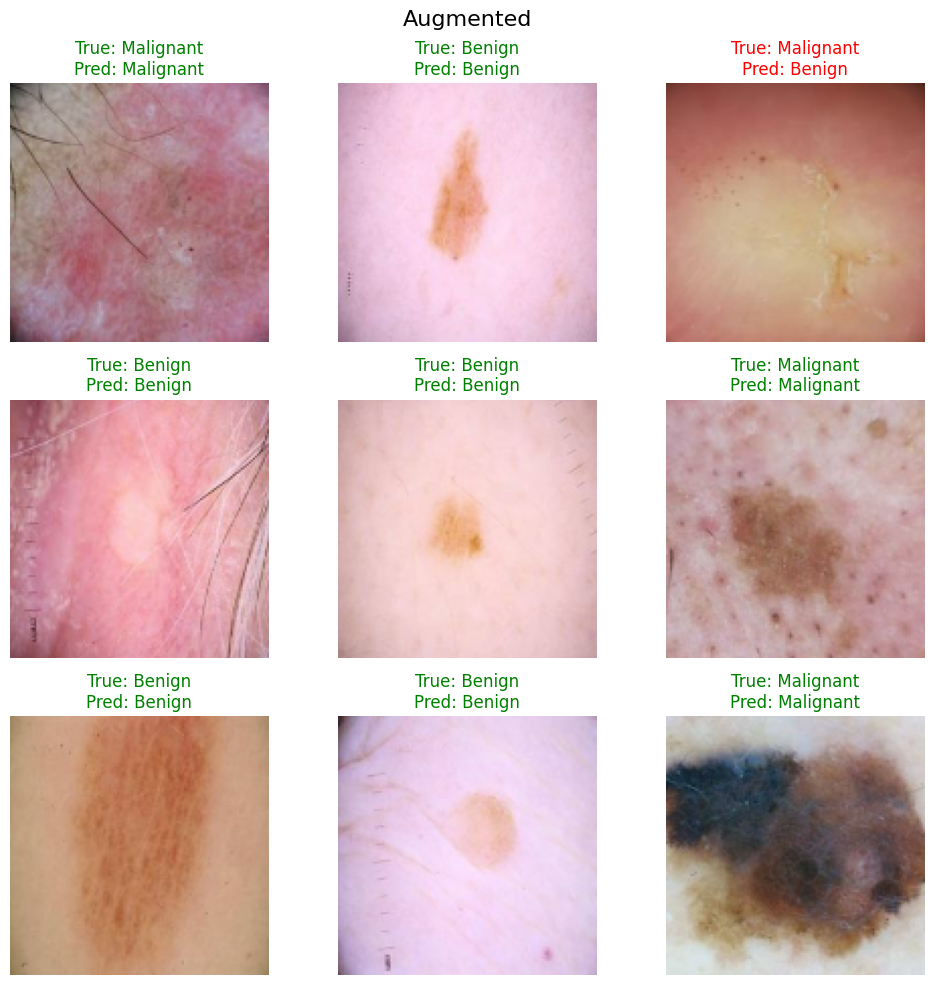

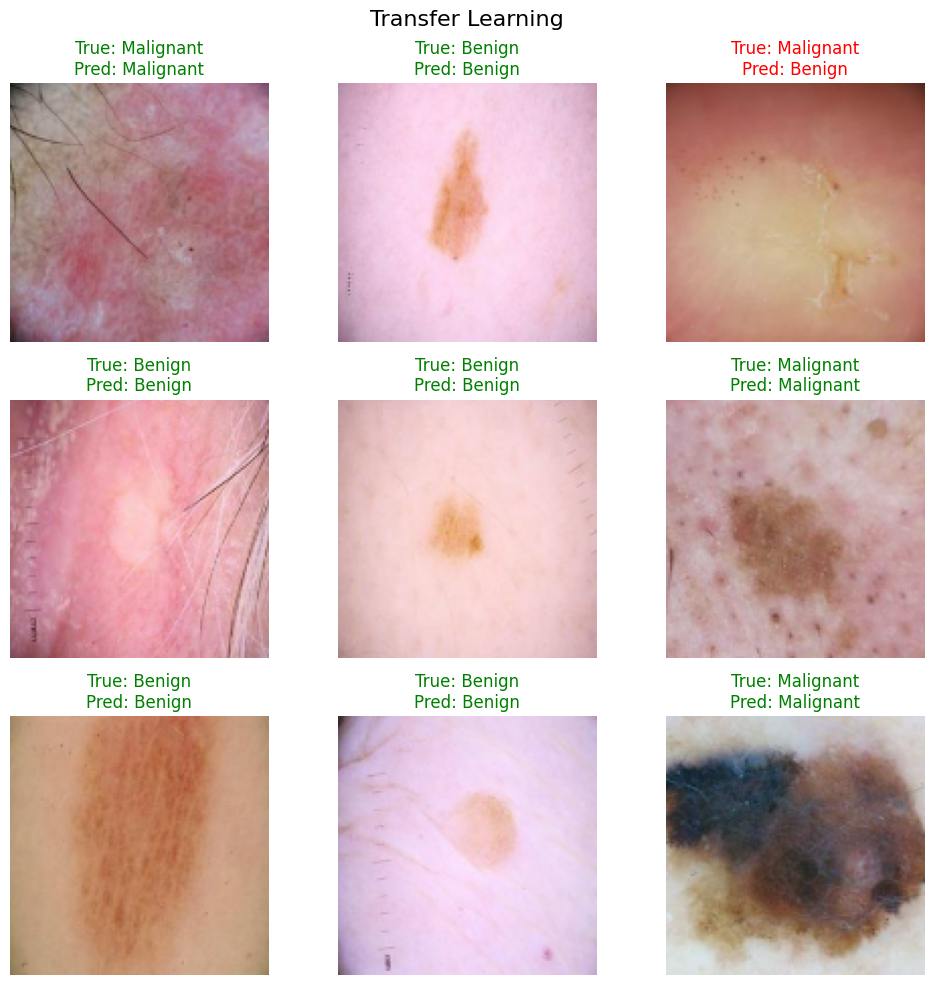

In [39]:
models = {
    "Baseline": model_baseline,
    "Augmented": model_aug,
    "Transfer Learning": model_tl
}

for name, model in models.items():
    plt.figure(figsize=(10, 10))
    plt.suptitle(name, fontsize=16)
    for images, labels in val_ds.take(1):
        preds = model.predict(images, verbose=0)
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[labels[i]]
            pred_label = class_names[np.argmax(preds[i])]
            color = "green" if true_label == pred_label else "red"
            plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

## Comparing between the validation accurecy for all models

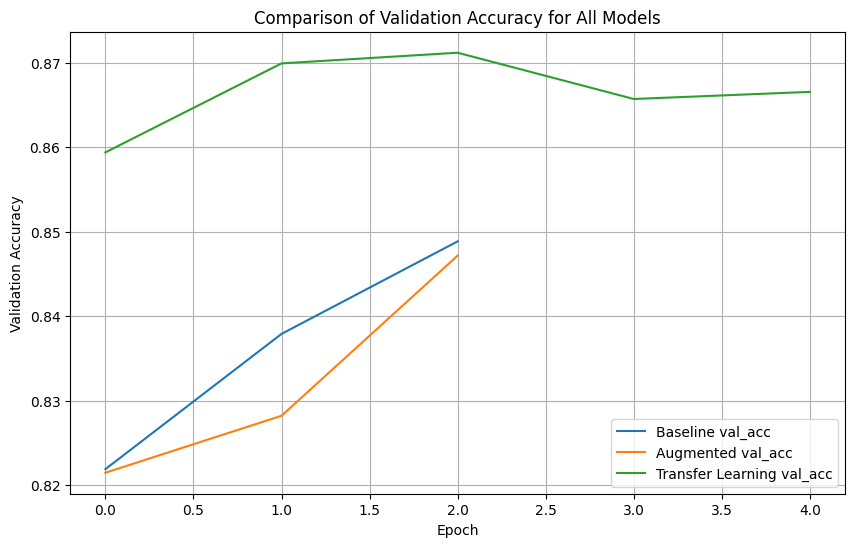

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline val_acc")
plt.plot(history_aug.history["val_accuracy"], label="Augmented val_acc")
plt.plot(history_tl.history["val_accuracy"], label="Transfer Learning val_acc")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Comparison of Validation Accuracy for All Models")
plt.legend()
plt.grid(True)
plt.show()

### Analysis
This visualization clearly shows that the Transfer Learning model with MobileNetV2 performed superiorly in terms of validation accuracy, reaching a high accuracy much faster and maintaining it, with a best validation accuracy of 0.8792.

In [41]:
for name, hist in [("Baseline", history_baseline), ("Augmented", history_aug), ("Transfer Learning", history_tl)]:
    best_val_acc = max(hist.history["val_accuracy"])
    epochs_run = len(hist.history["val_accuracy"])
    print(f"{name}: best val_accuracy = {best_val_acc:.4f}, epochs run = {epochs_run}")

Baseline: best val_accuracy = 0.8488, epochs run = 3
Augmented: best val_accuracy = 0.8472, epochs run = 3
Transfer Learning: best val_accuracy = 0.8712, epochs run = 5


## Results Summary

| Model                  | Val Accuracy | Training Time |
|-------------------------|--------------|----------------|
| Baseline CNN             | 0.8716       | 24.4s          |
| CNN + Augmentation       | 0.8632       | 19.7s          |
| Transfer Learning (MobileNetV2) | 0.8792       | 36.2s          |

**Which performed best and why:**
Transfer learning  outperformed both the customized models.
Custom Models Had to spend time learning basic shapes, edges, and colors from zero before trying to recognize skin cancer.
But the MobileNetV2 model Already learned how to recognize complex shapes and textures from millions of standard photos. It only needed a quick lesson on the difference between benign and malignant skin lesions, which also explains how fast the training time was for it.